In [1]:
import numpy as np 
import rebound
import os
import matplotlib.pyplot as plt
import dill
import pandas as pd

In [2]:
tess_offset =  2457000

# Definitions

In [3]:
def mean_anomaly(t, omega, e, Tc, P):
    """
    Calculate mean anomaly M at time t, given:
    - omega: argument of periastron (radians)
    - e: eccentricity
    - Tc: time of inferior conjunction (transit)
    - P: orbital period
    
    Converts Tc to periastron passage time tau using the formula:
    2*pi*(Tc - tau)/P = E0 - e*sin(E0)
    with E0 = 2 * arctan(sqrt((1-e)/(1+e)) * tan(pi/2 - omega/2))
    
    Returns mean anomaly M in radians [0, 2pi).
    """
    # Compute E0 from e and omega
    E0 = 2 * np.arctan( np.sqrt((1 - e) / (1 + e)) * np.tan(np.pi/4 - omega/2) )
    E0 = E0 % (2 * np.pi)

    # Compute time of periastron passage tau
    tau = Tc - (P / (2 * np.pi)) * (E0 - e * np.sin(E0))
    # print(tau[0], omega[0], e[0], Tc[0], P[0] )
    # print(f'tau: {tau[0]}') 
    # print(f'omega: {omega[0]}')
    # print(f'e: {e[0]}')
    # print(f'Tc: {Tc[0]}')
    # print(f'P: {P[0]}')

    # Compute mean anomaly at time t
    M = (2 * np.pi / P) * (t - tau)
    M = M % (2 * np.pi)

    return M


# Data

In [4]:
### get the posterior data
# file_name = '1339_jnkep_fit_1339-2000burn-2000step-emax0.5.pkl'
# file_name = 'mcmc_runs/1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5.pkl'
file_name = 'mcmc_runs/1339_jnkep_nburn-1000_nsteps-1000_hessian_tree-11_accept-95_emax-0.5_infl_err6.pkl'


working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [5]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)

posterior = mcmc.get_samples(group_by_chain=True)  # shape: (num_chains, num_samples, ...)
print({k: v.shape for k, v in posterior.items()})


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.42      0.09      0.44      0.28      0.52     43.49      1.11
 ecosw_scaled[1]      0.43      0.08      0.46      0.31      0.52     43.92      1.11
 esinw_scaled[0]      0.48      0.07      0.50      0.35      0.57    207.78      1.05
 esinw_scaled[1]      0.48      0.06      0.50      0.38      0.56    206.88      1.05
period_scaled[0]      0.50      0.00      0.50      0.50      0.50     48.13      1.10
period_scaled[1]      0.50      0.00      0.50      0.50      0.50    281.11      1.02
 pmass_scaled[0]      0.02      0.00      0.02      0.01      0.03    143.77      1.06
 pmass_scaled[1]      0.01      0.00      0.01      0.01      0.02     76.66      1.08
   tic_scaled[0]      0.48      0.01      0.48      0.47      0.49     32.09      1.14
   tic_scaled[1]      0.52      0.02      0.52      0.48      0.55    195.05      1.04

Number of divergences: 4
{'ecc': (8, 1000

In [7]:
good_chain_idxs = [0,2,3,5,6,7]

samples_filtered = {
    k: v[good_chain_idxs, ...] for k, v in posterior.items()
}
# print(samples_filtered)
samples = {
    k: v.reshape(-1, *v.shape[2:]) for k, v in samples_filtered.items()
}

# Shape of samples
print({k: v.shape for k, v in samples.items()})


{'ecc': (6000, 2), 'ecosw': (6000, 2), 'ecosw_scaled': (6000, 2), 'ediff': (6000,), 'esinw': (6000, 2), 'esinw_scaled': (6000, 2), 'period': (6000, 2), 'period_scaled': (6000, 2), 'pmass': (6000, 2), 'pmass_scaled': (6000, 2), 'tcmodel': (6000, 39), 'tic': (6000, 2), 'tic_scaled': (6000, 2)}


In [8]:
### conversions
solar_mass_2_kg = 1.989e30 # [kg per solar mass]
d_2_s = 86400 # [seconds per day]

### system constants 
m_star = 0.81  # [solar mass]

from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.AU**3 / u.M_sun / u.day**2).value


### posterior samples 
ecosw_c = samples["ecosw"][:, 0]
esinw_c = samples["esinw"][:, 0]
# e_c = samples["ecc"][:,0]
P_c = samples["period"][:,0] # [days]
Tc_c = samples["tic"][:,0] # [days]
m_c = samples["pmass"][:,0] # [solar mass]

ecosw_d = samples["ecosw"][:, 1]
esinw_d = samples["esinw"][:, 1]
# e_d = samples["ecc"][:,1]
P_d = samples["period"][:,1] # [days]
Tc_d = samples["tic"][:,1] # [days]
m_d = samples["pmass"][:,1] # [solar mass]  

### calculated params
a_c = np.array(((G_const*m_star*P_c**2)/(4*np.pi**2))**(1.0/3.)) # [AU]
a_d = np.array(((G_const*m_star*P_d**2)/(4*np.pi**2))**(1./3.)) # [AU]

e_c = np.sqrt(ecosw_c**2 + esinw_c**2)
e_d = np.sqrt(ecosw_d**2 + esinw_d**2)
omega_c = np.arctan2(esinw_c, ecosw_c) # [rad]
omega_d = np.arctan2(esinw_d, ecosw_d) # [rad]

# times = np.array([1980.] * len(omega_c))
times = Tc_d
ref_time = 0.0 # set to simulation start time

Mean_anomaly_c = mean_anomaly(ref_time, omega_c, e_c, Tc_c, P_c)
Mean_anomaly_d = mean_anomaly(ref_time, omega_d, e_d, Tc_d, P_d)

### keep Omega constant
value_Omega_c = 0  # [deg]
Omega_c = np.full_like(omega_c, np.radians(value_Omega_c))
value_Omega_d = 0 # [deg]
Omega_d = np.full_like(omega_d, np.radians(value_Omega_d))

pomega_c = omega_c + Omega_c
pomega_d = omega_d + Omega_d
lambda_c = omega_c + Omega_c + Mean_anomaly_c
lambda_d = omega_d + Omega_d + Mean_anomaly_d

# Set fixed inclination (e.g. edge-on)
inc_c = [np.pi / 2] * len(a_c)
inc_d = [np.pi / 2] * len(a_d)

print(a_c)
print(m_c)
print(np.array(Omega_c))

[0.17053558 0.17053571 0.17053537 ... 0.17053522 0.17053565 0.17053428]
[2.5761245e-05 2.5212201e-05 2.1335949e-05 ... 2.0735992e-05 2.0514124e-05
 2.5158664e-05]
[0. 0. 0. ... 0. 0. 0.]


In [9]:
r_apo_c = a_c * (1 + e_c)
r_peri_d = a_d * (1 - e_d)
initially_crossed=[]
for i in range(len(r_apo_c)):
    r_apo = r_apo_c[i]
    r_peri = r_peri_d[i]
    if r_peri < r_apo:
        initially_crossed.append(i)

print(f'Systems where initial posterior state has r_peri_d < r_apo_c: {len(initially_crossed)}')

Systems where initial posterior state has r_peri_d < r_apo_c: 3021


In [10]:
# Set parameters (fixed values from literature) Polanski, orell-miquel
from astropy.constants import M_jup, M_sun
mass_b = 0.0302 * (M_jup / M_sun)
a_b = 0.079
e_b = 0.0
omega_b = np.radians(90.)
Omega_b = 0.0 # assume 0
inc_b = np.pi / 2
Tc_b = 2458715.35572 - tess_offset
P_b = 8.8803232



mass_e = 0.3590 * (M_jup / M_sun)  # MJup to Msun
a_e = 0.400
e_e = 0.0
omega_e = np.radians(230.0)
Omega_e = 0.0  # Assume 0 for simplicity
inc_e = np.pi / 2  # edge-on
Tc_e = 2459044.0 - tess_offset
P_e = 101.5

# Reference time = same as for other planets
# t_ref = times[i]  # or pick a fixed time like 2459000

M_e = mean_anomaly(np.median(Tc_d), omega_e, e_e, Tc_e, P_e)
M_b = mean_anomaly(np.median(Tc_d), omega_b, e_b, Tc_b, P_b)

pomega_b = omega_b + Omega_b
pomega_e = omega_e + Omega_e
lambda_b = omega_b + Omega_b + M_b
lambda_e = omega_e + Omega_e + M_e

# Check stability
only return true if no encounter, escape, or exception

In [11]:
def simulate_draw(i, m_star, a_c, a_d, m_c, m_d, e_c, e_d, inc_c, inc_d,
                  Omega_c, Omega_d, omega_c, omega_d, M_c, M_d,
                  tmax=1e6):
    """
    Simulate a single posterior draw for two planets and return True if stable.
    Assumes units: AU, Msun, days.
    dt in years?
    """
    sim = rebound.Simulation()
    sim.units = ('AU', 'day', 'Msun')
    sim.G = G_const  # Set your custom G if using AU/day²/Msun

    # Central star
    sim.add(m=m_star)

    # Planet b
    sim.add(m=mass_b,
        a=a_b,
        e=e_b,
        inc=inc_b,
        Omega=Omega_b,
        omega=omega_b,
        M=M_b)

    # Planet c
    sim.add(m=m_c[i],
            a=a_c[i],
            e= e_c[i],
            inc=inc_c[i],
            Omega=Omega_c[i],
            omega= omega_c[i],
            M=M_c[i])

    # Planet d
    sim.add(m=m_d[i],
            a=a_d[i],
            e= e_d[i],
            inc=inc_d[i],
            Omega=Omega_d[i],
            omega=omega_d[i],
            M=M_d[i])

    # Planet e
    sim.add(m=mass_e,
        a=a_e,
        e=e_e,
        inc=inc_e,
        Omega=Omega_e,
        omega=omega_e,
        M=M_e)

    
    sim.move_to_com()
    sim.integrator = "whfast"
    dt = P_b/20
    sim.dt = dt

    # Optional: encounter detection
    r_hill = a_c[i] * np.sqrt(m_c[i] / (3*m_star))
    sim.exit_min_distance = r_hill  # [AU], or adjust to Roche limit

    try:
        Noutputs =  20000 #int(tmax / dt) # number of points along orbit

        # arrays to store positions
        Nplanets = len(sim.particles) - 1  # skip star
        x = np.zeros((Noutputs, Nplanets))
        y = np.zeros((Noutputs, Nplanets))
        z = np.zeros((Noutputs, Nplanets))
        e = np.zeros((Noutputs, Nplanets))
        a = np.zeros((Noutputs, Nplanets))
        inc = np.zeros((Noutputs, Nplanets))
        # choose times: 0 → tmax
        times = np.linspace(0, tmax, Noutputs)

        # dt_output = tmax / Noutputs
        for k, t in enumerate(times):
            sim.integrate(t)
        
            for j in range(Nplanets):
                p = sim.particles[j+1]  # skip star at index 0
                x[k,j] = p.x
                y[k,j] = p.y
                z[k,j] = p.z 
                e[k,j] = p.e
                a[k,j] = p.a
                inc[k,j] = p.inc
                
        # sim.integrate(tmax)

        
        if (e[:,0] >= 1.0).any() or (e[:,1] >= 1.0).any() or (e[:,2]>=1.0).any() or (e[:,3]>= 1.0).any():
            note = "escape or unbound"
            print(note)
            return False, note, sim, x, y, z, e, a, inc

        cross_times = []
        for k in range(Noutputs):
            Q_c = a[k,1] * (1 + e[k,1]) # apo for inner planet 
            q_d = a[k,2] * (1 - e[k,2]) # peri for outer planet
            
            if q_d < Q_c:
                cross_times.append(times[k])
                # note = "orbit crossing"
                # print(note)
                # return False, note, sim, x, y, z, e, a, inc
        if cross_times:
            note = "orbit crossing"
            print(note)
            return False, note, sim, x, y, z, e, a, inc
        else:        
            note='stable'
            print(note)
            return True, note, sim, x, y, z, e, a, inc

    except rebound.Encounter:
        note = f"encounter"
        print(note)
        return False, note, sim, x, y, z, e, a, inc
    


In [12]:
n_draws = 5  # or whatever number feels fast enough
N_total = len(P_c)  # assuming all arrays are same length

# Choose `n_draws` unique random indices
random_indices = np.random.choice(N_total, size=n_draws, replace=False)

# random_indices = [4815, 3739, 445, 5777]
# random_indices=[1823]
# random_indices = [1]

print(random_indices)

[5046 1636 4853 3241 4144]


28580984.115600586
stable
[[0.079      0.17053485 0.20746239 0.4       ]
 [0.07899954 0.17051461 0.20745765 0.40000188]
 [0.07899989 0.17051965 0.20743262 0.40000201]
 ...
 [0.07900074 0.1705156  0.20755672 0.39999701]
 [0.07899984 0.17051749 0.20745536 0.40000124]
 [0.07899996 0.17050935 0.20750332 0.39999955]]
[[0.00000000e+00 5.96897677e-02 5.04518524e-02 4.42802107e-17]
 [6.28273364e-05 5.99308710e-02 5.00578240e-02 2.53914207e-05]
 [1.97494351e-04 5.97058909e-02 5.00597159e-02 4.18741721e-05]
 ...
 [1.26542516e-02 5.99668505e-02 4.48950362e-02 1.07745392e-03]
 [1.27047698e-02 6.00060495e-02 4.53747796e-02 1.08924076e-03]
 [1.27940459e-02 6.01248202e-02 4.43133815e-02 1.10857204e-03]]


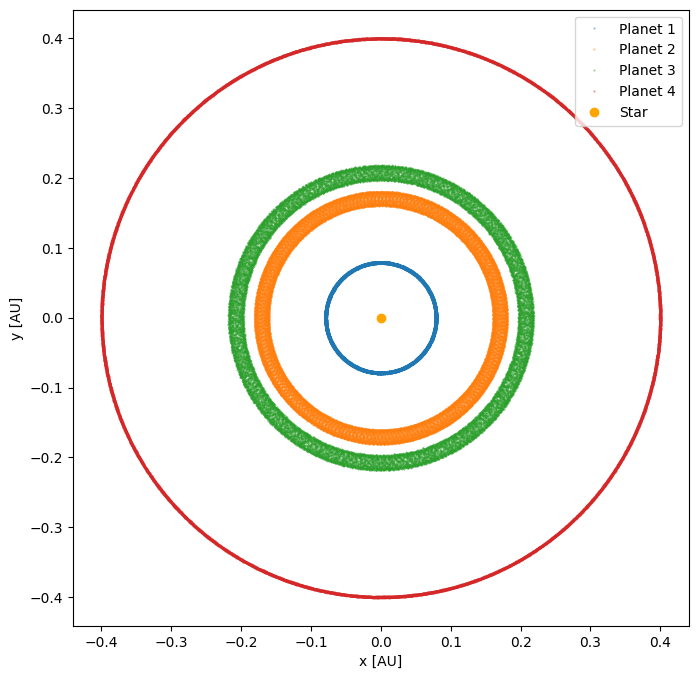

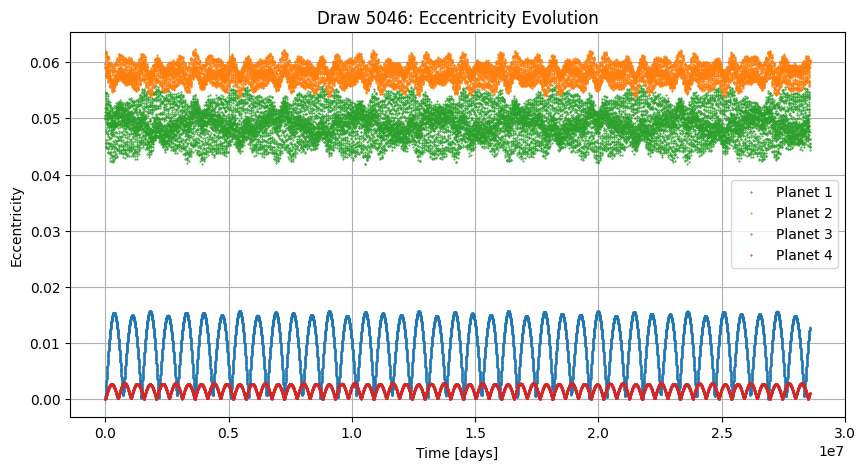

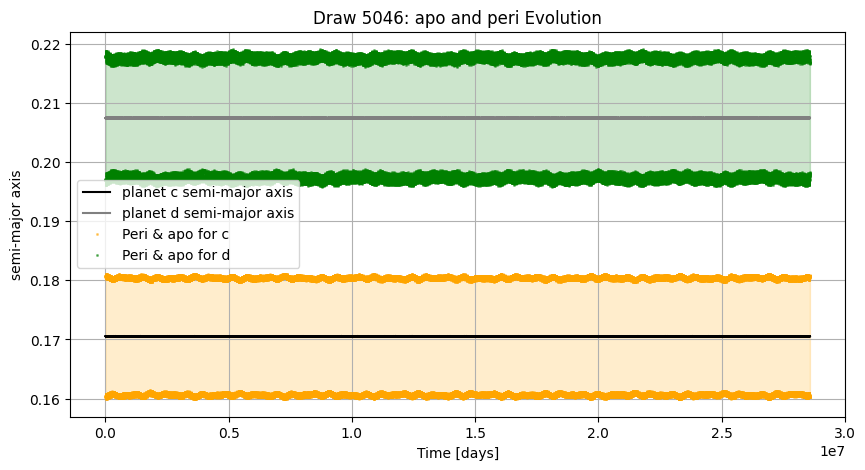

[0.18071403 0.1807337  0.18070068 ... 0.18074088 0.18074957 0.18076119]
[0.19699552 0.19707277 0.1970486  ... 0.19823845 0.19804212 0.19830815]
stable
[[0.079      0.17053536 0.20746085 0.4       ]
 [0.07899947 0.17051609 0.20744649 0.40000245]
 [0.07899984 0.17051847 0.20742556 0.40000301]
 ...
 [0.07900043 0.17054604 0.20744138 0.39999983]
 [0.07900001 0.1705252  0.20751766 0.39999846]
 [0.07899976 0.17050804 0.2074664  0.40000219]]
[[0.00000000e+00 9.46732413e-04 8.11854610e-04 1.80845331e-16]
 [4.16224516e-05 1.02919438e-03 3.20231950e-03 1.23800760e-05]
 [1.20106616e-05 8.17316486e-04 2.09324736e-03 1.19483132e-05]
 ...
 [2.44218271e-05 9.73677972e-04 8.30718525e-04 4.88721498e-05]
 [4.54151424e-05 1.16645817e-03 4.58112439e-04 4.60549553e-05]
 [1.70435197e-05 9.26372315e-04 2.29045466e-03 5.07870846e-05]]


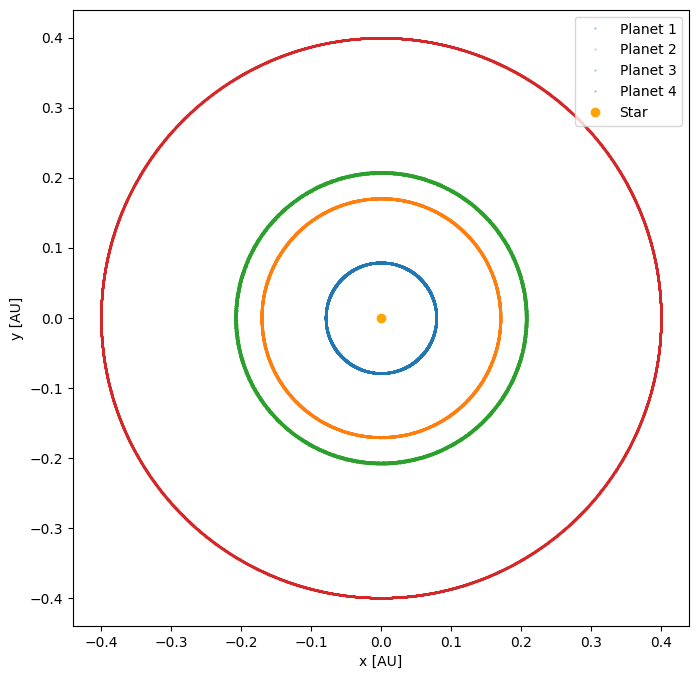

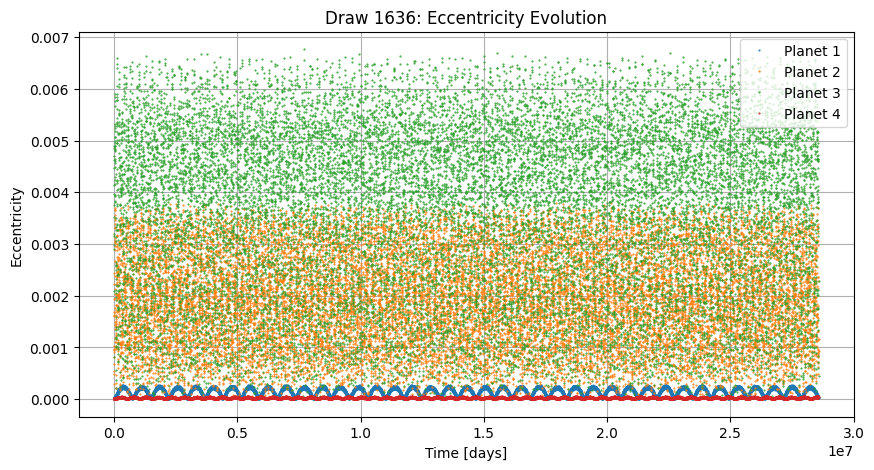

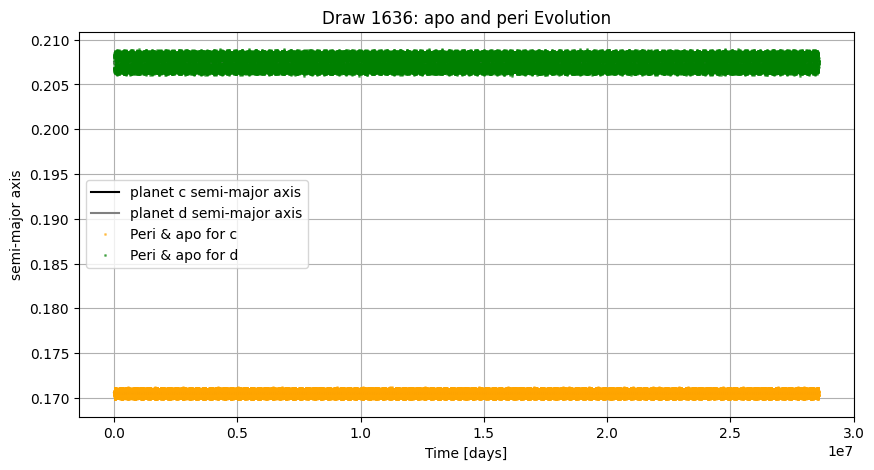

[0.17069681 0.17069158 0.17065783 ... 0.1707121  0.17072411 0.170666  ]
[0.20729242 0.20678218 0.20699136 ... 0.20726905 0.2074226  0.20699121]
stable
[[0.079      0.17053583 0.20746216 0.4       ]
 [0.07899955 0.1705134  0.20744976 0.40000223]
 [0.07899986 0.17051876 0.2074254  0.40000344]
 ...
 [0.07899976 0.17051316 0.20747462 0.40000111]
 [0.0790006  0.17051283 0.20752903 0.39999836]
 [0.0790002  0.17050098 0.20748448 0.40000155]]
[[0.00000000e+00 1.56740621e-02 1.44972540e-02 1.86187111e-16]
 [7.90156567e-05 1.62315007e-02 1.27988575e-02 1.65823973e-05]
 [7.77309862e-05 1.63112069e-02 1.37898731e-02 8.50544882e-06]
 ...
 [4.03064175e-03 1.78592511e-02 1.01081730e-02 9.71754093e-05]
 [4.01587688e-03 1.77505022e-02 1.18781721e-02 8.82017893e-05]
 [4.03050071e-03 1.76184292e-02 1.10316857e-02 7.95701408e-05]]


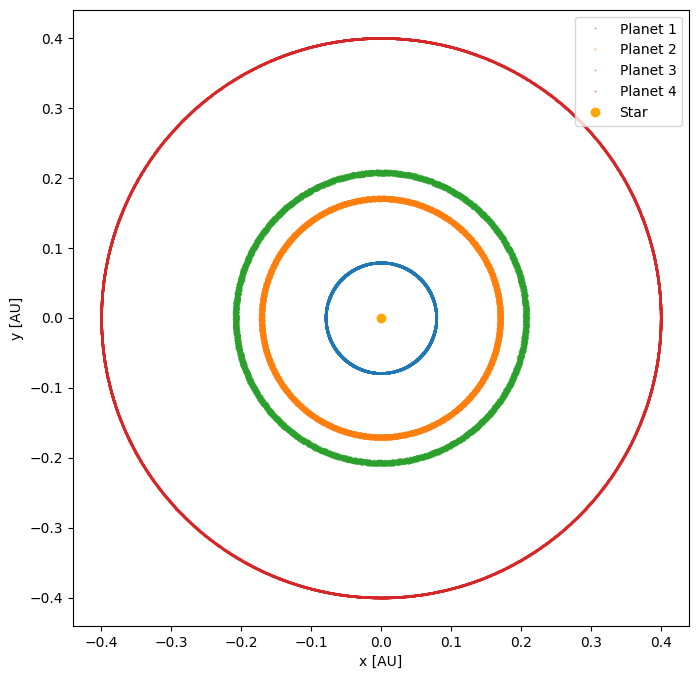

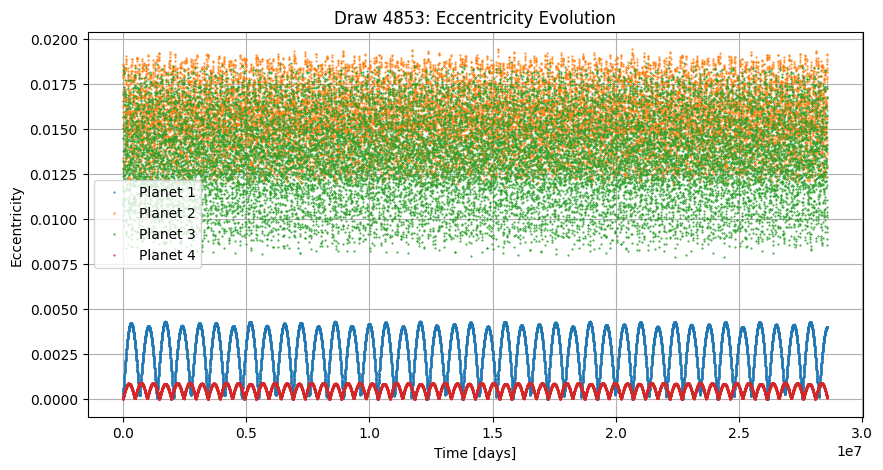

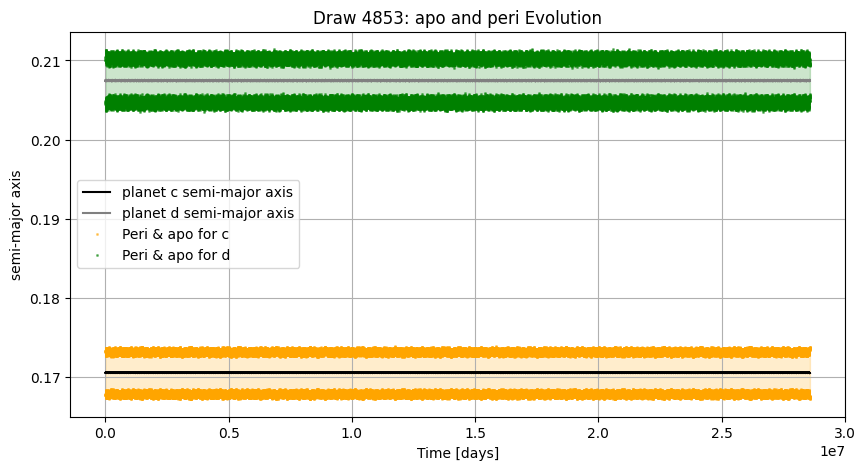

[0.17320882 0.17328109 0.17330012 ... 0.1735584  0.17353952 0.17350494]
[0.20445453 0.20479464 0.20456503 ... 0.20537743 0.20506396 0.20519558]
orbit crossing
[[0.079      0.1705348  0.20746292 0.4       ]
 [0.07899953 0.17050719 0.20749726 0.39999941]
 [0.07900029 0.17051798 0.20744979 0.40000142]
 ...
 [0.07899917 0.17052931 0.20755977 0.39999037]
 [0.07899947 0.17055217 0.20743144 0.39999916]
 [0.07900001 0.1705428  0.20751921 0.39998926]]
[[0.00000000e+00 1.77584380e-01 1.51540056e-01 1.80844643e-16]
 [4.69726115e-04 1.77768577e-01 1.50917375e-01 1.14082412e-04]
 [8.51136379e-04 1.77700427e-01 1.51164216e-01 1.93205165e-04]
 ...
 [3.41410106e-02 1.75887114e-01 1.47580046e-01 4.26235817e-04]
 [3.39599828e-02 1.75564009e-01 1.49270808e-01 3.85841208e-04]
 [3.36114612e-02 1.75504080e-01 1.47747552e-01 3.80883398e-04]]


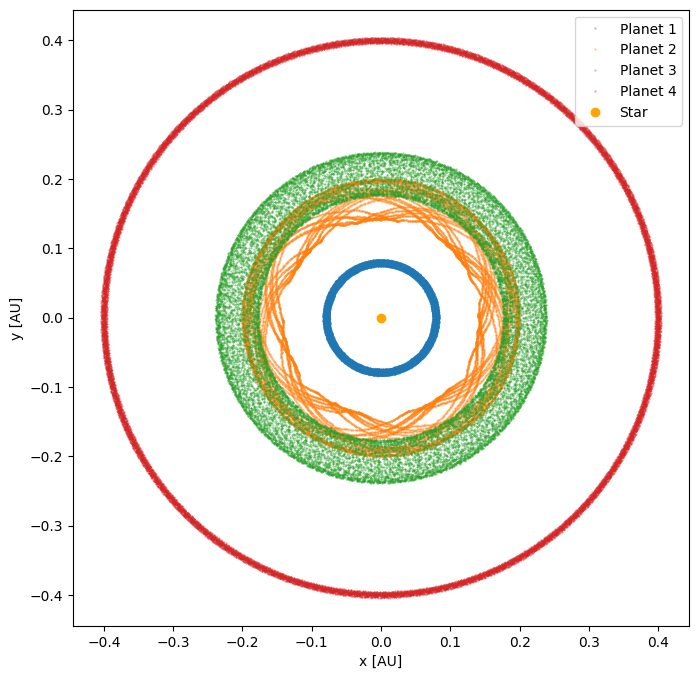

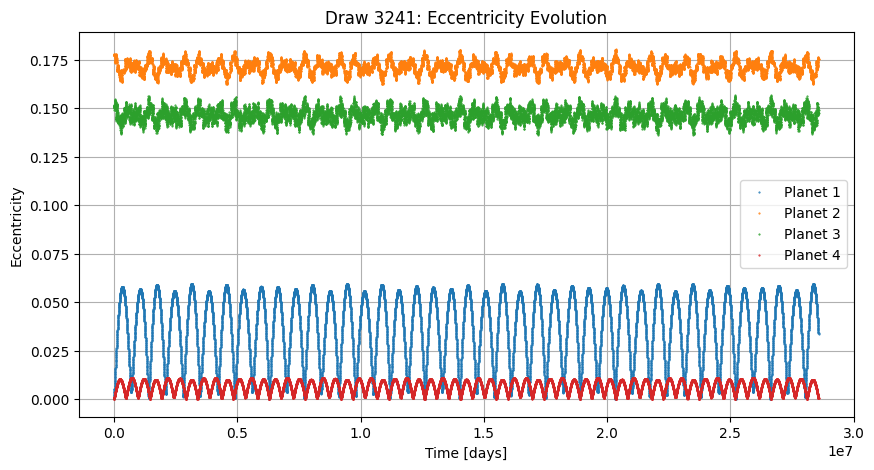

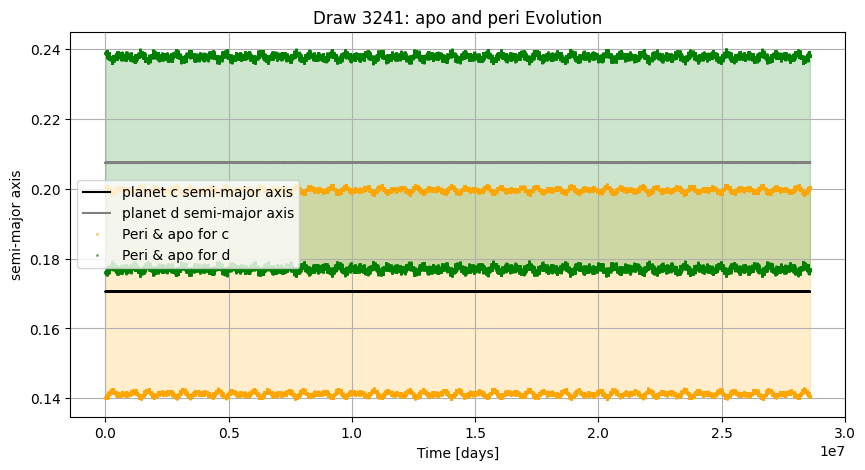

[0.20081912 0.20081801 0.2008191  ... 0.20052321 0.200495   0.20047376]
[0.17602398 0.17618232 0.1760908  ... 0.17692809 0.17646798 0.17685876]
stable
[[0.079      0.17053528 0.20746332 0.4       ]
 [0.07899951 0.17051269 0.20745643 0.40000208]
 [0.07899981 0.17051958 0.20742877 0.40000292]
 ...
 [0.07899978 0.17051368 0.20752605 0.39999807]
 [0.07900012 0.17052892 0.20743226 0.40000213]
 [0.07900045 0.17052215 0.20747098 0.40000046]]
[[0.00000000e+00 2.57016085e-02 2.08365079e-02 0.00000000e+00]
 [7.64156148e-05 2.63102493e-02 1.91934118e-02 8.19737686e-06]
 [8.81467270e-05 2.60234873e-02 1.97482275e-02 1.71518170e-05]
 ...
 [7.02980890e-03 2.24839783e-02 2.16054163e-02 1.25596306e-03]
 [6.98989712e-03 2.25691470e-02 2.24722644e-02 1.27020246e-03]
 [7.02547332e-03 2.27620973e-02 2.19119056e-02 1.27159093e-03]]


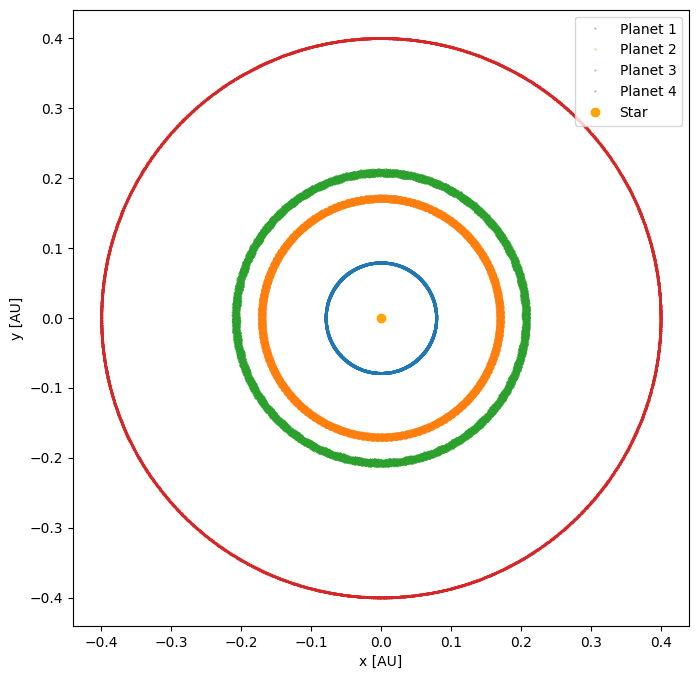

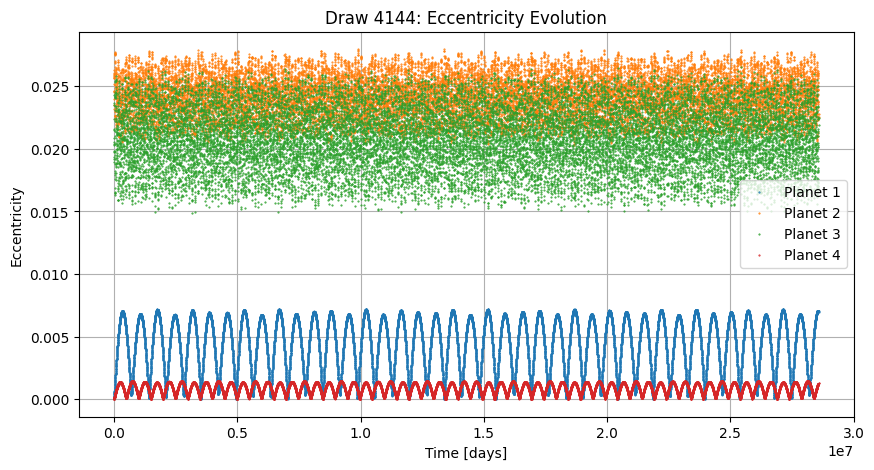

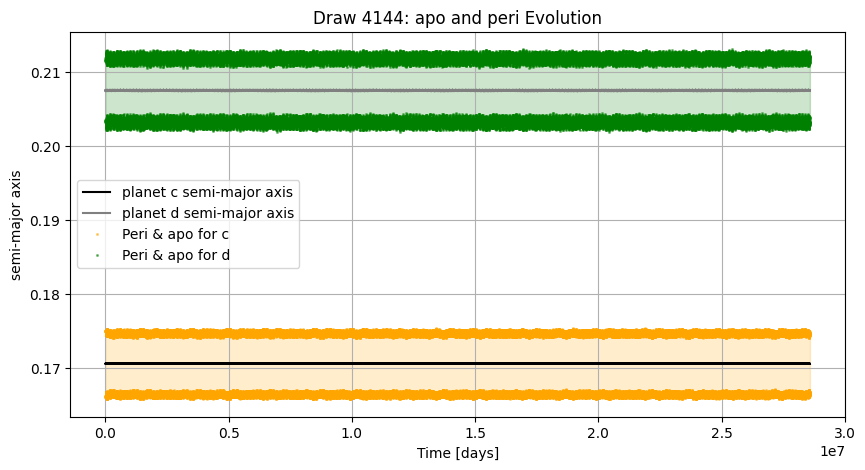

[0.17491831 0.17499892 0.17495709 ... 0.17434751 0.17437761 0.17440359]
[0.20314051 0.20347464 0.20333241 ... 0.20304237 0.20277079 0.20292489]
[True, True, True, False, True]
['stable', 'stable', 'stable', 'orbit crossing', 'stable']
[5046, 1636, 4853, 3241, 4144]


In [13]:
tmax = 1e6 * np.median(P_c)
print(tmax)
draw_idx = []
results = []
notes = []
sims = []

master_data = []
os.makedirs("sim_details", exist_ok=True)

for i in random_indices:
    stable, note, sim, x, y, z, e, a, inc = simulate_draw(
        i=i,
        m_star=m_star,
        a_c=a_c, a_d=a_d,
        m_c=m_c, m_d=m_d,
        e_c=e_c, e_d=e_d,
        inc_c=inc_c, inc_d=inc_d,
        Omega_c=Omega_c, Omega_d=Omega_d,
        omega_c=omega_c, omega_d=omega_d,
        M_c=Mean_anomaly_c, M_d=Mean_anomaly_d,
        tmax = tmax
    )
    draw_idx.append(i)
    results.append(stable)
    notes.append(note)
    sims.append(sim)
    # rebound.OrbitPlotSet(sim)
    print(a)
    print(e)

    # SAVE DATA
    # Create per-simulation dataframe for integration steps
    times = np.linspace(0, tmax, len(e))  # len(e) is number of timesteps
    step_df = pd.DataFrame({"time_days": times})
    
    Nplanets = e.shape[1]  # number of planets
    
    for p in range(Nplanets):
        step_df[f"x_p{p+1}"] = x[:, p]
        step_df[f"y_p{p+1}"] = y[:, p]
        step_df[f"z_p{p+1}"] = z[:, p]
        step_df[f"e_p{p+1}"] = e[:, p]
        step_df[f"a_p{p+1}"] = a[:, p]
        step_df[f"inc_p{p+1}"] = inc[:, p]
    
    # # Save per-simulation dataframe
    # step_filename = f"sim_details/sim_{i}.csv"
    # step_df.to_csv(step_filename, index=False)

    # # Add a row to master dataframe list
    # master_data.append({
    #     "draw_index": i,
    #     "stable": stable,
    #     "note": note,
    #     "m_b": mass_b, "a_b": a_b, "e_b": e_b, "inc_b": inc_b, "Omega_b": Omega_b, "omega_b": omega_b, "M_b": M_b,
    #     "m_c": m_c[i], "a_c": a_c[i], "e_c": e_c[i], "inc_c": inc_c[i], "Omega_c": Omega_c[i], "omega_c": omega_c[i], "M_c": Mean_anomaly_c[i],
    #     "m_d": m_d[i], "a_d": a_d[i], "e_d": e_d[i], "inc_d": inc_d[i], "Omega_d": Omega_d[i], "omega_d": omega_d[i], "M_d": Mean_anomaly_d[i],
    #     "m_e": mass_e, "a_e": a_e, "e_e": e_e, "inc_e": inc_e, "Omega_e": Omega_e, "omega_e": omega_e, "M_e": M_e,
    #     "detail_file": step_filename
    # })
    



    # PLOTS
    # orbit plot
    plt.figure(figsize=(8,8))
    Nplanets = len(sim.particles) - 1  # skip star
    for j in range(Nplanets):
        plt.plot(x[:,j], z[:,j], '.', markersize=1, alpha=0.5, label=f'Planet {j+1}')
    plt.plot(0,0,'o', color='orange', label='Star')
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel('x [AU]')
    plt.ylabel('y [AU]')
    plt.legend()
    plt.show()

    # eccentricity plot 
    # --- Eccentricity evolution plot ---
    plt.figure(figsize=(10,5))
    times = np.linspace(0, tmax, len(e))
    for j in range(Nplanets):
        plt.plot(times, e[:,j], '.', markersize=1, label=f'Planet {j+1}')
    plt.xlabel('Time [days]')
    plt.ylabel('Eccentricity')
    plt.title(f"Draw {i}: Eccentricity Evolution")
    plt.legend()
    plt.grid(True)
    plt.show()

    # plt.figure(figsize=(10,5))
    # for j in range(Nplanets):
    #     plt.plot(times, a[:,j], '.', markersize=1, label=f'Planet {j+1}')
    # plt.title(f'Draw {i}: semi-major axis Evolution')
    # plt.xlabel('Time [days]')
    # plt.ylabel('semi-major axis')
    # plt.legend()
    # plt.grid(True)
    # plt.show()


    # plt.figure(figsize=(10,5))
    peri_c = a[:,1] * (1 - e[:,1])
    apo_c = a[:,1] * (1 + e[:,1])
    peri_d = a[:,2] * (1 - e[:,2])
    apo_d = a[:,2] * (1 + e[:,2])
    # plt.plot(times, peri_d, '.', markersize=1, color='green', label=f'Peri d')
    # plt.plot(times, apo_c, '.', markersize=1, color='orange', label=f'Apo c')
    # plt.xlabel('Time [days]')
    # plt.ylabel('apo and peri')
    # plt.title(f"Draw {i}: apo and peri Evolution")
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    plt.figure(figsize=(10,5))
    plt.plot(times, a[:,1], color='black', label=f'planet c semi-major axis')
    plt.plot(times, a[:,2], color='grey', label=f'planet d semi-major axis')
    # plt.plot(times, e[:,1], '.', markersize=1, color='orange', label=f'planet c')
    # plt.plot(times, e[:,2], '.', markersize=1, color='green', label=f'planet d')
    plt.plot(times, peri_c, 's', markersize=1, color='orange', alpha=0.5, label=f'Peri & apo for c')
    plt.plot(times, apo_c, 's', markersize=1, color='orange', alpha=0.5)#,  label=f'Apo c')
    plt.plot(times, peri_d, 's', markersize=1, color='green', alpha=0.5, label=f'Peri & apo for d')
    plt.plot(times, apo_d, 's', markersize=1, color='green', alpha=0.5)#,  label=f'Apo d')

    # Fill between same-colored lines
    plt.fill_between(times, peri_c, apo_c, color='orange', alpha=0.2)  # Green shaded area
    plt.fill_between(times, peri_d, apo_d, color='green', alpha=0.2)   # Orange shaded area

    plt.xlabel('Time [days]')
    plt.ylabel('semi-major axis')
    plt.title(f"Draw {i}: apo and peri Evolution")
    plt.legend(loc='center left')
    plt.grid(True)
    plt.show()

    print(apo_c)
    print(peri_d)
        



# master_df = pd.DataFrame(master_data)
# master_file_name = "simulation_master.csv"
# master_df.to_csv(master_file_name, index=False)
# print(f"Saved master summary to {master_file_name} with {len(master_df)} simulations")


print(results)
print(notes)
print(draw_idx)

In [14]:
stable_count = sum(results)
total = len(results)
stable_fraction = stable_count / total
print(f"Fraction of stable posterior draws: {stable_fraction:.2f}")
print(f"{stable_count} stable of {total} total systems")

Fraction of stable posterior draws: 0.80
4 stable of 5 total systems


In [15]:
true_indices = [i for i, val in enumerate(results) if val]
from astropy.constants import M_earth, M_sun

draws = [draw_idx[i] for i in true_indices]
for draw in draws:
    m2=m_c[draw]
    a2=a_c[draw]
    e2=e_c[draw]
    inc2=inc_c[draw]
    Omega2=Omega_c[draw]            
    omega2=omega_c[draw]
    M2=Mean_anomaly_c[draw]
    apo_2 = a2*(1+e2)

    # Planet d
    m3=m_d[draw]
    a3=a_d[draw]
    e3=e_d[draw]
    inc3=inc_d[draw]
    Omega3=Omega_d[draw]
    omega3=omega_d[draw]
    M3=Mean_anomaly_d[draw]
    peri_3 = a3*(1+e3)

    print(f'mass 2: {m2 / (M_earth / M_sun)}')
    print(f'mass 3: {m3 / (M_earth / M_sun)}')
    print(f'ecc 2: {e2}')
    print(f'ecc 3: {e3}')
    print(f'apo 2: {apo_2}')
    print(f'peri 3: {peri_3}')
    print('\n')


mass 2: 5.7111005783081055
mass 3: 3.0634658336639404
ecc 2: 0.05968976765871048
ecc 3: 0.0504518523812294
apo 2: 0.18071403469135383
peri 3: 0.21792924693447457


mass 2: 6.394259929656982
mass 3: 3.4886474609375
ecc 2: 0.000946732412558049
ecc 3: 0.0008118546102195978
apo 2: 0.1706968071551797
peri 3: 0.20762927852511864


mass 2: 5.828028678894043
mass 3: 4.545532703399658
ecc 2: 0.015674062073230743
ecc 3: 0.01449725404381752
apo 2: 0.17320882187007336
peri 3: 0.21046979344319927


mass 2: 6.229041576385498
mass 3: 4.3060688972473145
ecc 2: 0.025701608508825302
ecc 3: 0.02083650790154934
apo 2: 0.17491831233747374
peri 3: 0.21178613526124257




In [16]:
# all orbit draw eccentricities 
for draw in draw_idx:
    m2=m_c[draw]
    a2=a_c[draw]
    e2=e_c[draw]
    inc2=inc_c[draw]
    Omega2=Omega_c[draw]            
    omega2=omega_c[draw]
    M2=Mean_anomaly_c[draw]
    apo_2 = a2*(1+e2)

    # Planet d
    m3=m_d[draw]
    a3=a_d[draw]
    e3=e_d[draw]
    inc3=inc_d[draw]
    Omega3=Omega_d[draw]
    omega3=omega_d[draw]
    M3=Mean_anomaly_d[draw]
    peri_3 = a3*(1-e3)

    print(f'ecc 2: {e2}')
    print(f'ecc 3: {e3}')
    print(f'apo 2: {apo_2}')
    print(f'peri 3: {peri_3}')
    print('\n')




ecc 2: 0.05968976765871048
ecc 3: 0.0504518523812294
apo 2: 0.18071403469135383
peri 3: 0.19699552365916861


ecc 2: 0.000946732412558049
ecc 3: 0.0008118546102195978
apo 2: 0.1706968071551797
peri 3: 0.2072924224293186


ecc 2: 0.015674062073230743
ecc 3: 0.01449725404381752
apo 2: 0.17320882187007336
peri 3: 0.2044545301156081


ecc 2: 0.17758437991142273
ecc 3: 0.15154005587100983
apo 2: 0.20081912196733276
peri 3: 0.17602397898719047


ecc 2: 0.025701608508825302
ecc 3: 0.02083650790154934
apo 2: 0.17491831233747374
peri 3: 0.20314051287871104




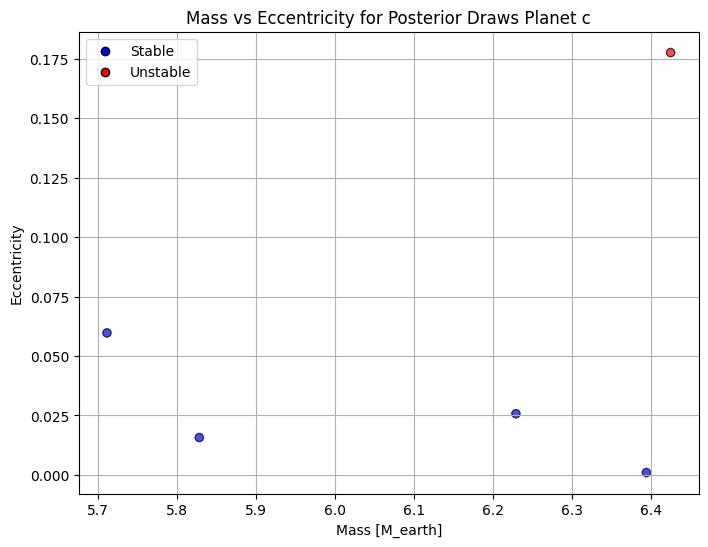

In [17]:
# Store planet mass and eccentricity for each draw
mass_list = []
ecc_list = []
color_list = []
from astropy.constants import M_earth, M_sun
m_c_earth = m_c / (M_earth / M_sun)

for i_idx, draw in enumerate(draw_idx):
    # Example: Planet b
    m_planet = m_c_earth[draw]   # mass
    e_planet = e_c[draw]   # eccentricity
    
    mass_list.append(m_planet)
    ecc_list.append(e_planet)
    
    # Color by stability
    if results[i_idx]:
        color_list.append('blue')   # stable
    else:
        color_list.append('red')    # unstable

# Now plot all draws
plt.figure(figsize=(8,6))
plt.scatter(mass_list, ecc_list, c=color_list, edgecolor='k', alpha=0.7)
# Add dummy points for legend
plt.scatter([], [], c='blue', edgecolor='k', label='Stable')
plt.scatter([], [], c='red', edgecolor='k', label='Unstable')

plt.xlabel("Mass [M_earth]")  # adjust units to match your data
plt.ylabel("Eccentricity")
plt.title("Mass vs Eccentricity for Posterior Draws Planet c")
plt.legend()
plt.grid(True)
plt.show()

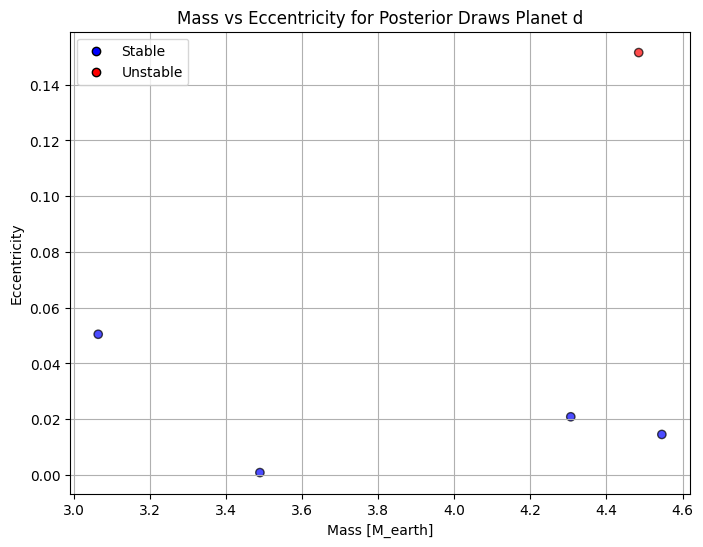

In [18]:
# Store planet mass and eccentricity for each draw
mass_list = []
ecc_list = []
color_list = []

m_d_earth = m_d / (M_earth / M_sun)

for i_idx, draw in enumerate(draw_idx):
    # Example: Planet b
    m_planet = m_d_earth[draw]   # mass
    e_planet = e_d[draw]   # eccentricity
    
    mass_list.append(m_planet)
    ecc_list.append(e_planet)
    
    # Color by stability
    if results[i_idx]:
        color_list.append('blue')   # stable
    else:
        color_list.append('red')    # unstable

# Now plot all draws
plt.figure(figsize=(8,6))
plt.scatter(mass_list, ecc_list, c=color_list, edgecolor='k', alpha=0.7)
# Add dummy points for legend
plt.scatter([], [], c='blue', edgecolor='k', label='Stable')
plt.scatter([], [], c='red', edgecolor='k', label='Unstable')

plt.xlabel("Mass [M_earth]")  # adjust units to match your data
plt.ylabel("Eccentricity")
plt.title("Mass vs Eccentricity for Posterior Draws Planet d")
plt.legend()
plt.grid(True)
plt.show()